# EDA - Phát hiện dữ liệu ngoại lệ

Notebook này là điểm vào cho phần phát hiện outlier. Logic chính nằm trong `EDA/src/04_detect_outliers.py` để có thể chạy lại ổn định bằng script.

In [1]:
from pathlib import Path
import subprocess
import sys

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parents[1]
elif not (ROOT / "EDA").exists():
    ROOT = ROOT.parents[0]

SCRIPT = ROOT / "EDA" / "src" / "04_detect_outliers.py"
REPORT = ROOT / "EDA" / "docs" / "04-outliers" / "04_outliers_report.md"
FIGURE_DIR = ROOT / "EDA" / "outputs" / "figures" / "04_outliers"
TABLE_DIR = ROOT / "EDA" / "outputs" / "tables" / "04_outliers"

ROOT

WindowsPath('d:/Tài liệu Bách khoa/DataWarehouse/BTN')

## Chạy lại kiểm tra outlier

In [2]:
subprocess.run([sys.executable, str(SCRIPT)], cwd=ROOT, check=True)

CompletedProcess(args=['d:\\Tài liệu Bách khoa\\DataWarehouse\\BTN\\.venv\\Scripts\\python.exe', 'd:\\Tài liệu Bách khoa\\DataWarehouse\\BTN\\EDA\\src\\04_detect_outliers.py'], returncode=0)

## Report

In [3]:
from IPython.display import Markdown, display

display(Markdown(REPORT.read_text(encoding="utf-8")))

# Báo Cáo EDA - Phát Hiện Dữ Liệu Ngoại Lệ

## 1. Phạm vi

Phần này phát hiện giá trị bất thường trong dữ liệu OULAD sau ELT. Kết quả chỉ gắn cờ và mô tả, không tự động xóa outlier. Với OULAD, một số outlier có thể là hành vi học tập thật, ví dụ sinh viên tương tác VLE rất nhiều trước assessment.

## 2. Quy tắc đã dùng

- `score` hợp lệ trong khoảng 0 đến 100.
- `sum_click` không được âm. Dòng `sum_click = 0` được thống kê như tín hiệu cần xem tỷ lệ, không mặc định là lỗi.
- Sinh viên có `total_click` rất cao được phát hiện bằng IQR trong từng module-presentation.
- Submission quá sớm nếu `date_submitted - date < -60` ngày.
- Submission quá muộn nếu `date_submitted - date > 30` ngày.
- `weight` assessment hợp lệ trong khoảng 0 đến 100. Tổng weight được tách `Exam` và non-Exam vì OULAD có thể chấm exam riêng với coursework.

## 3. Nhận xét chính

- `score` ngoài khoảng 0-100: 0 dòng.
- Dòng raw `studentVle.sum_click = 0`: 0 trên 9,868,110 dòng, chiếm 0.0%.
- Dòng raw `studentVle.sum_click < 0`: 0 dòng.
- Sinh viên có `total_click = 0`: 3,365 bản ghi student-module-presentation.
- Sinh viên có `total_click` cao theo IQR trong module-presentation: 1,615 bản ghi.
- Weekly activity có `weekly_click < 0`: 0 dòng.
- Weekly activity có `weekly_click` cao theo IQR: 41,329 dòng.
- Submission quá sớm hơn 60 ngày so với hạn: 18,037 dòng.
- Submission quá muộn hơn 30 ngày so với hạn: 471 dòng.
- Assessment có `weight = 0`: 56 dòng.
- Module-presentation có tổng non-Exam weight khác 100: 3 nhóm.
- Module-presentation có tổng Exam weight khác 100: 2 nhóm.

Đọc diễn giải chi tiết tại [04_outliers_insights.md](04_outliers_insights.md).

## 4. Diễn giải

- Không phát hiện `score` âm hoặc lớn hơn 100, nên điểm assessment cơ bản nằm trong khoảng hợp lý.
- Không phát hiện `sum_click` âm, nên biến click không có lỗi âm rõ ràng.
- `sum_click = 0` và `total_click = 0` nên được giữ lại để phân tích nhóm ít hoặc không tương tác, không tự động xóa.
- Các submission quá sớm/quá muộn nên được kiểm tra trong bối cảnh deadline của từng assessment.
- Assessment có `weight = 0` hoặc tổng Exam/non-Exam khác 100 cần ghi chú vì có thể là đặc thù thiết kế đánh giá, không nhất thiết là lỗi.

## 5. Bảng đầu ra

- `EDA/outputs/tables/04_outliers/assessment_weight_by_module_presentation.csv`
- `EDA/outputs/tables/04_outliers/assessment_weight_outliers.csv`
- `EDA/outputs/tables/04_outliers/assessment_weight_summary.csv`
- `EDA/outputs/tables/04_outliers/outlier_summary_by_module_presentation.csv`
- `EDA/outputs/tables/04_outliers/raw_sum_click_by_module_presentation.csv`
- `EDA/outputs/tables/04_outliers/raw_sum_click_summary.csv`
- `EDA/outputs/tables/04_outliers/score_range_outliers.csv`
- `EDA/outputs/tables/04_outliers/score_range_summary.csv`
- `EDA/outputs/tables/04_outliers/student_click_outlier_summary_by_module_presentation.csv`
- `EDA/outputs/tables/04_outliers/student_click_outliers.csv`
- `EDA/outputs/tables/04_outliers/submission_timing_by_module_presentation.csv`
- `EDA/outputs/tables/04_outliers/submission_timing_outliers.csv`
- `EDA/outputs/tables/04_outliers/submission_timing_summary.csv`
- `EDA/outputs/tables/04_outliers/weekly_click_outlier_summary_by_module_presentation.csv`
- `EDA/outputs/tables/04_outliers/weekly_click_outliers.csv`

## 6. Biểu đồ đầu ra

- `EDA/outputs/figures/04_outliers/assessment_total_weight_by_module_presentation.png`
- `EDA/outputs/figures/04_outliers/assessment_weight_exam_non_exam_scatter.png`
- `EDA/outputs/figures/04_outliers/high_total_click_rate_by_module_presentation.png`
- `EDA/outputs/figures/04_outliers/outlier_rate_heatmap_by_module_presentation.png`
- `EDA/outputs/figures/04_outliers/student_total_click_boxplot_by_module_presentation.png`
- `EDA/outputs/figures/04_outliers/submission_delay_distribution.png`
- `EDA/outputs/figures/04_outliers/submission_timing_outliers_by_module_presentation.png`
- `EDA/outputs/figures/04_outliers/submission_timing_scatter_by_module_presentation.png`

## 7. Khuyến nghị xử lý

- Giữ outlier trong dữ liệu EDA ban đầu.
- Khi trực quan hóa click, dùng log scale hoặc winsorized view để tránh vài giá trị lớn che khuất phần còn lại.
- Nếu xây mô hình, tạo flag như `is_zero_click`, `is_high_click_iqr`, `is_very_late_submission`.
- So sánh outlier theo module-presentation thay vì chỉ nhìn toàn bộ dữ liệu.


## Bảng và biểu đồ đã sinh

In [4]:
import pandas as pd

pd.DataFrame({"table": sorted(path.name for path in TABLE_DIR.glob("*.csv"))})

,table
0,assessment_weight_by_module_presentation.csv
1,assessment_weight_outliers.csv
2,assessment_weight_summary.csv
3,outlier_summary_by_module_presentation.csv
4,raw_sum_click_by_module_presentation.csv
5,raw_sum_click_summary.csv
6,score_range_outliers.csv
7,score_range_summary.csv
8,student_click_outlier_summary_by_module_presen...
9,student_click_outliers.csv


assessment_total_weight_by_module_presentation.png


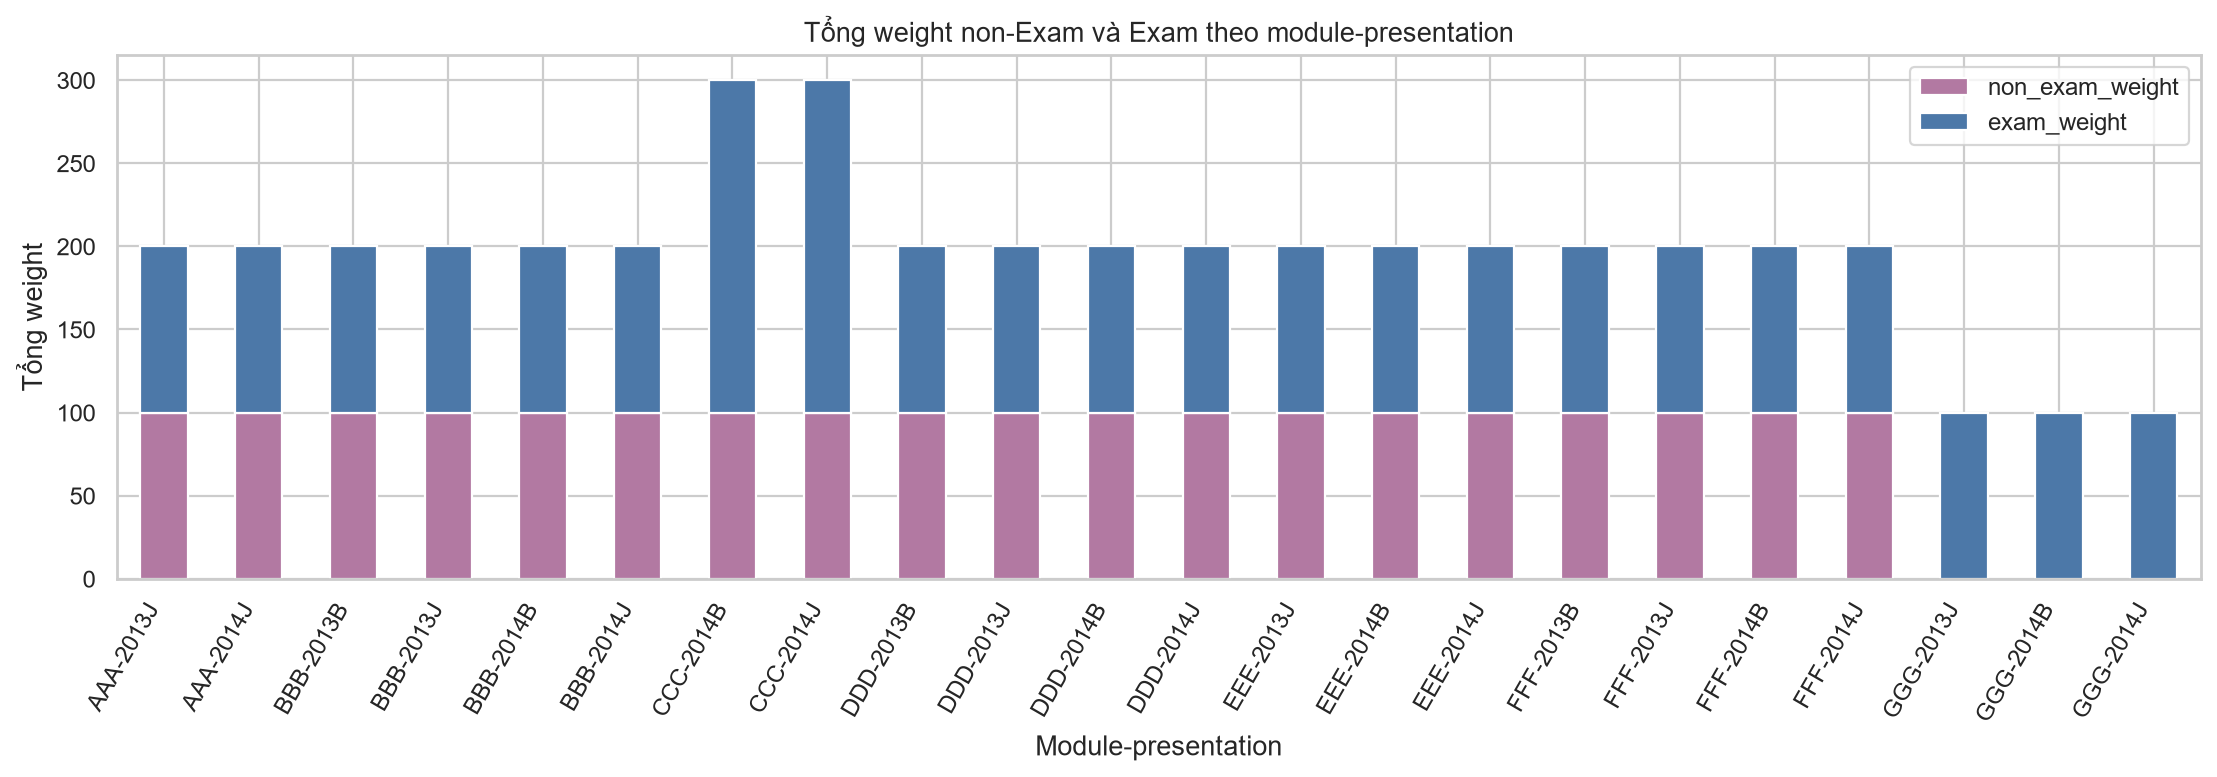

assessment_weight_exam_non_exam_scatter.png


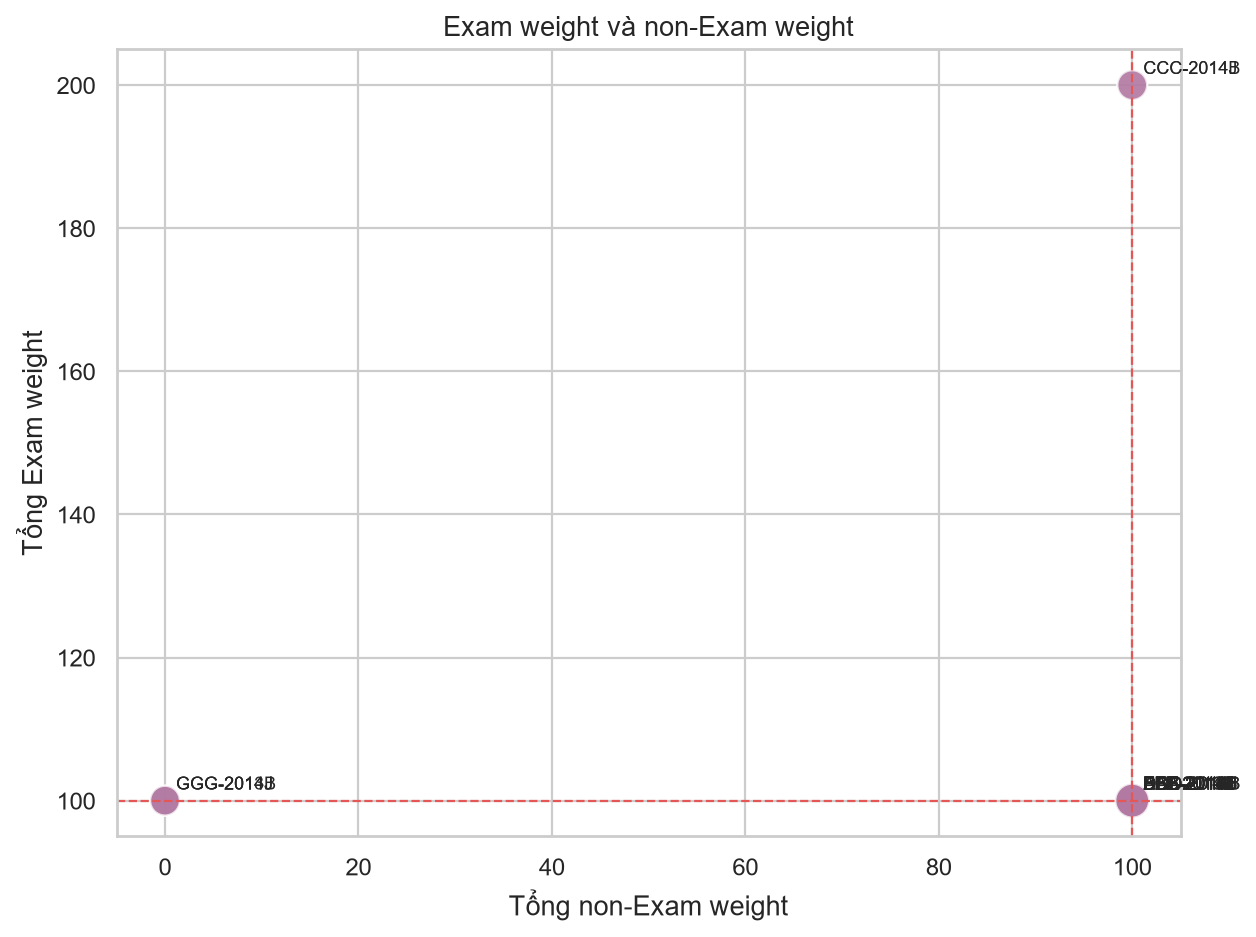

high_total_click_rate_by_module_presentation.png


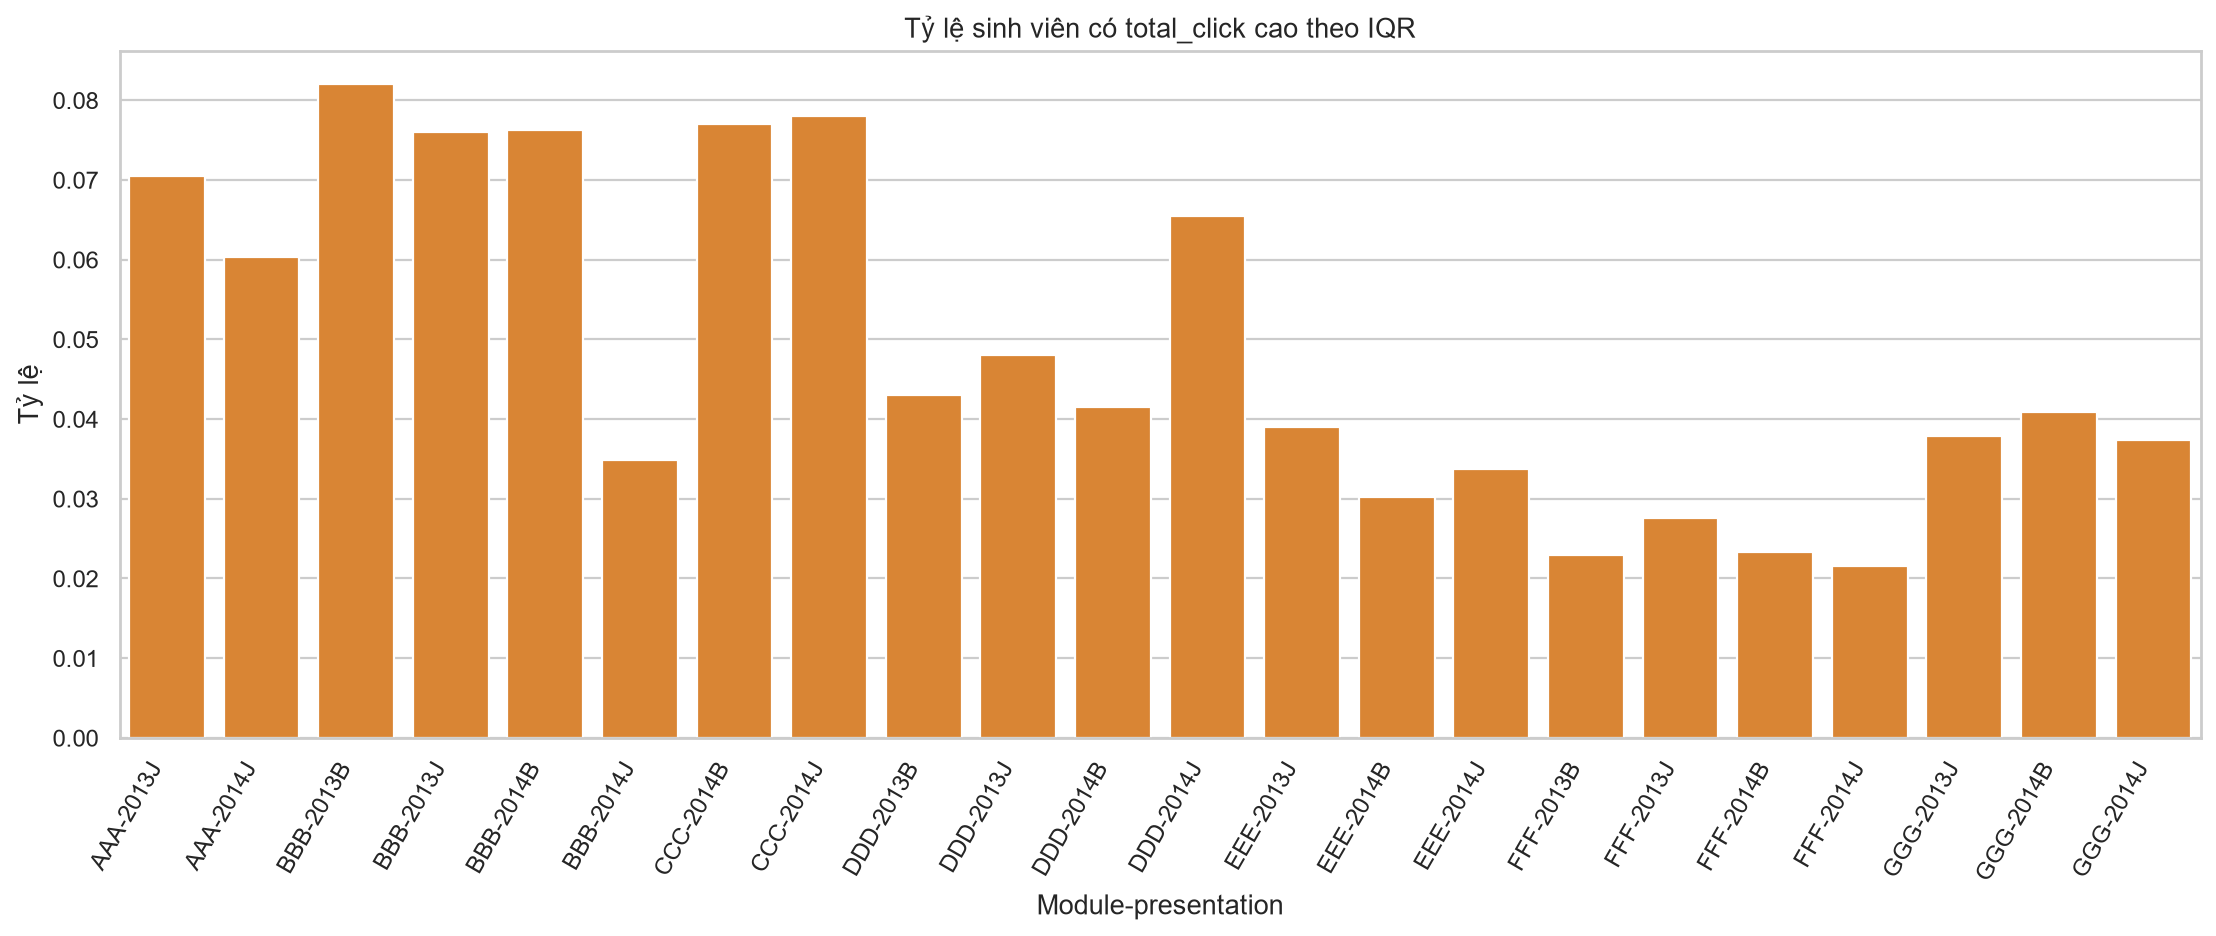

outlier_rate_heatmap_by_module_presentation.png


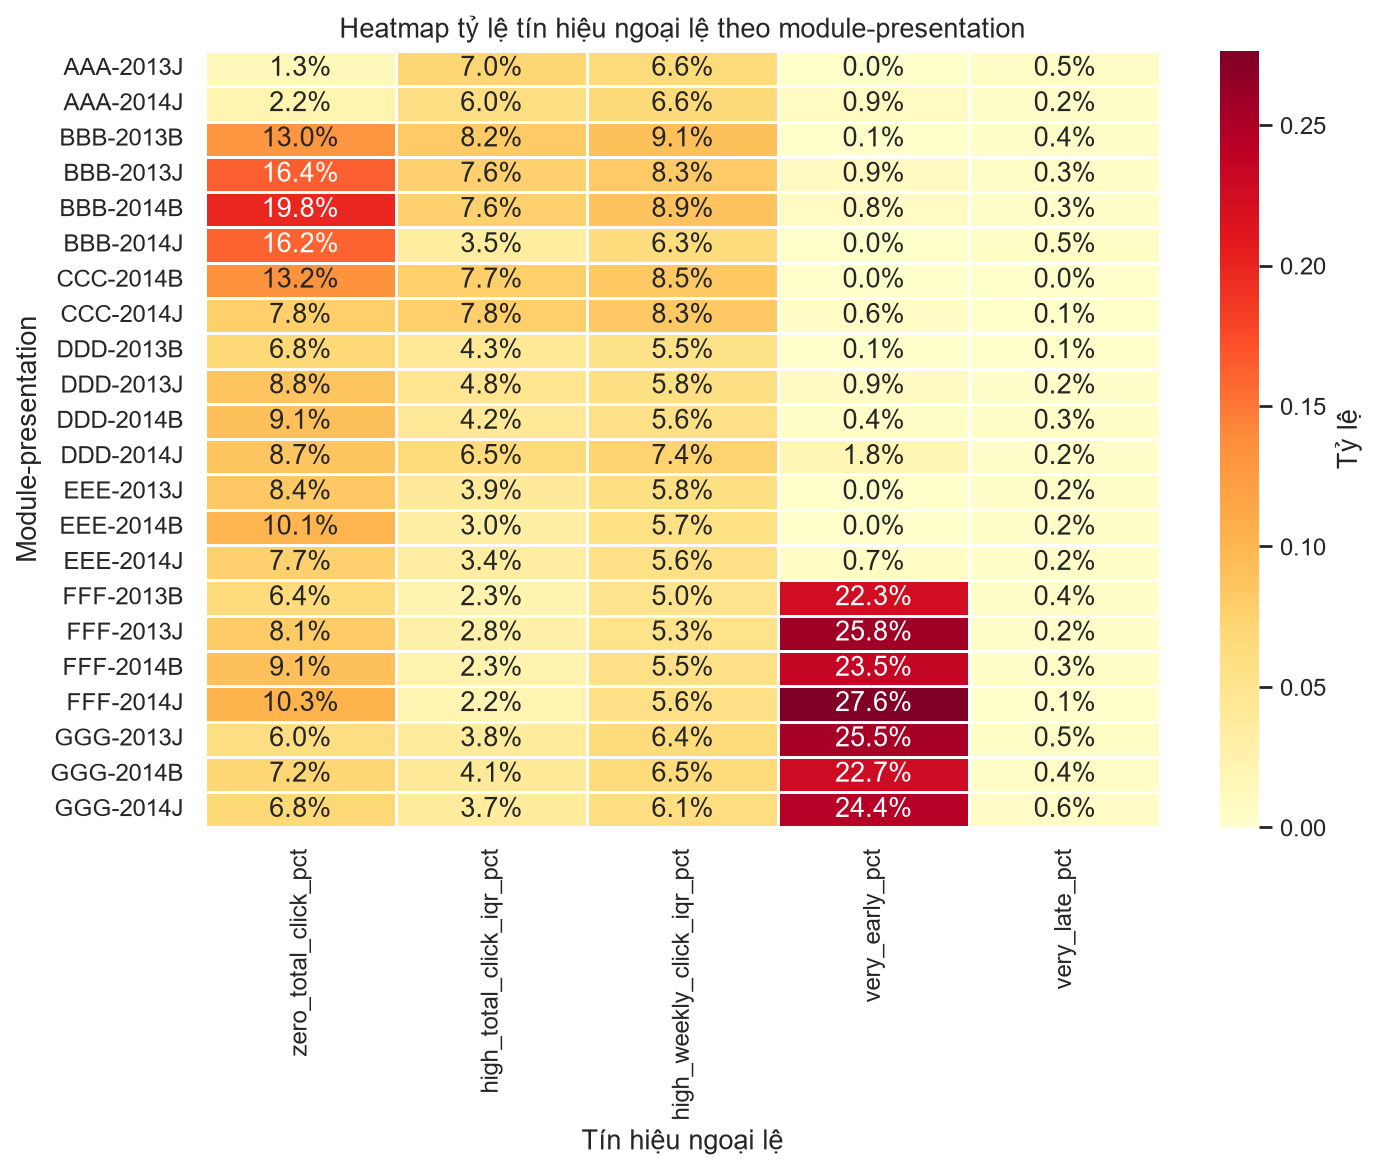

student_total_click_boxplot_by_module_presentation.png


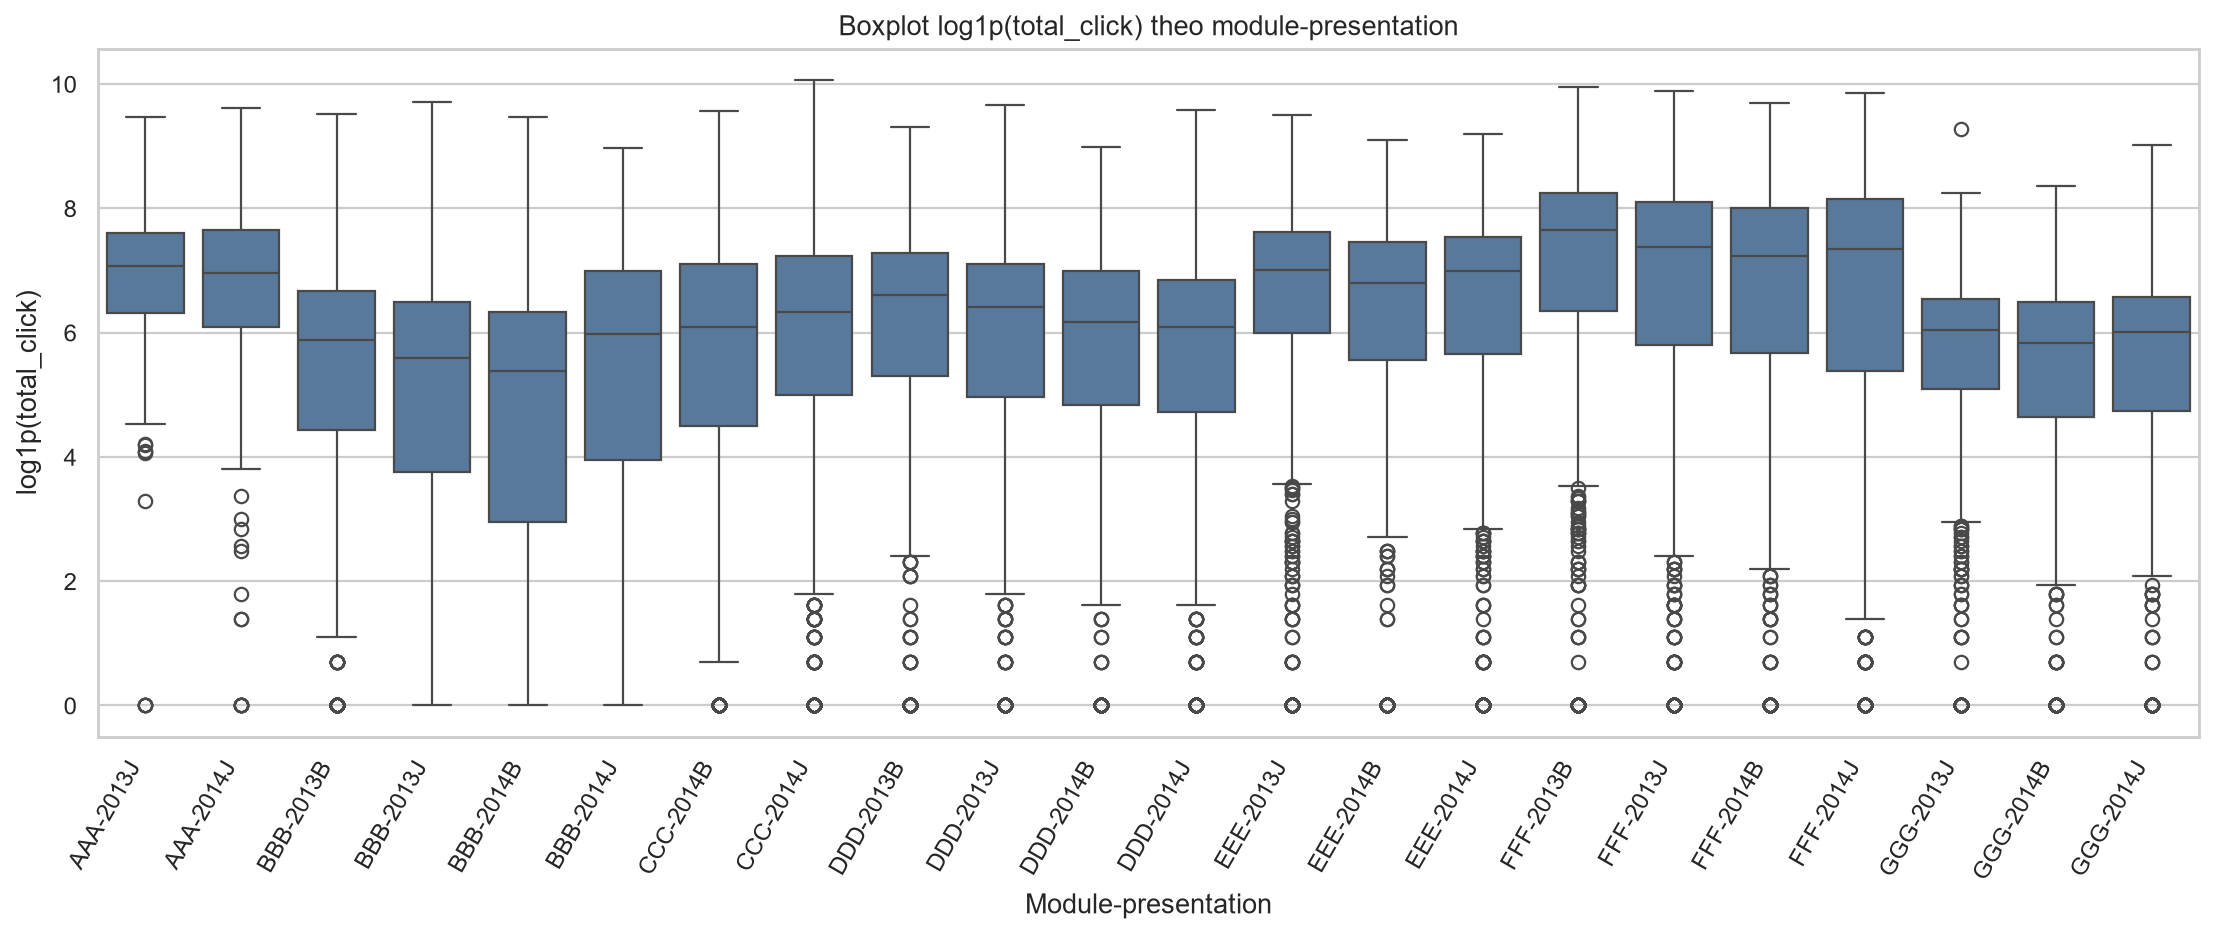

submission_delay_distribution.png


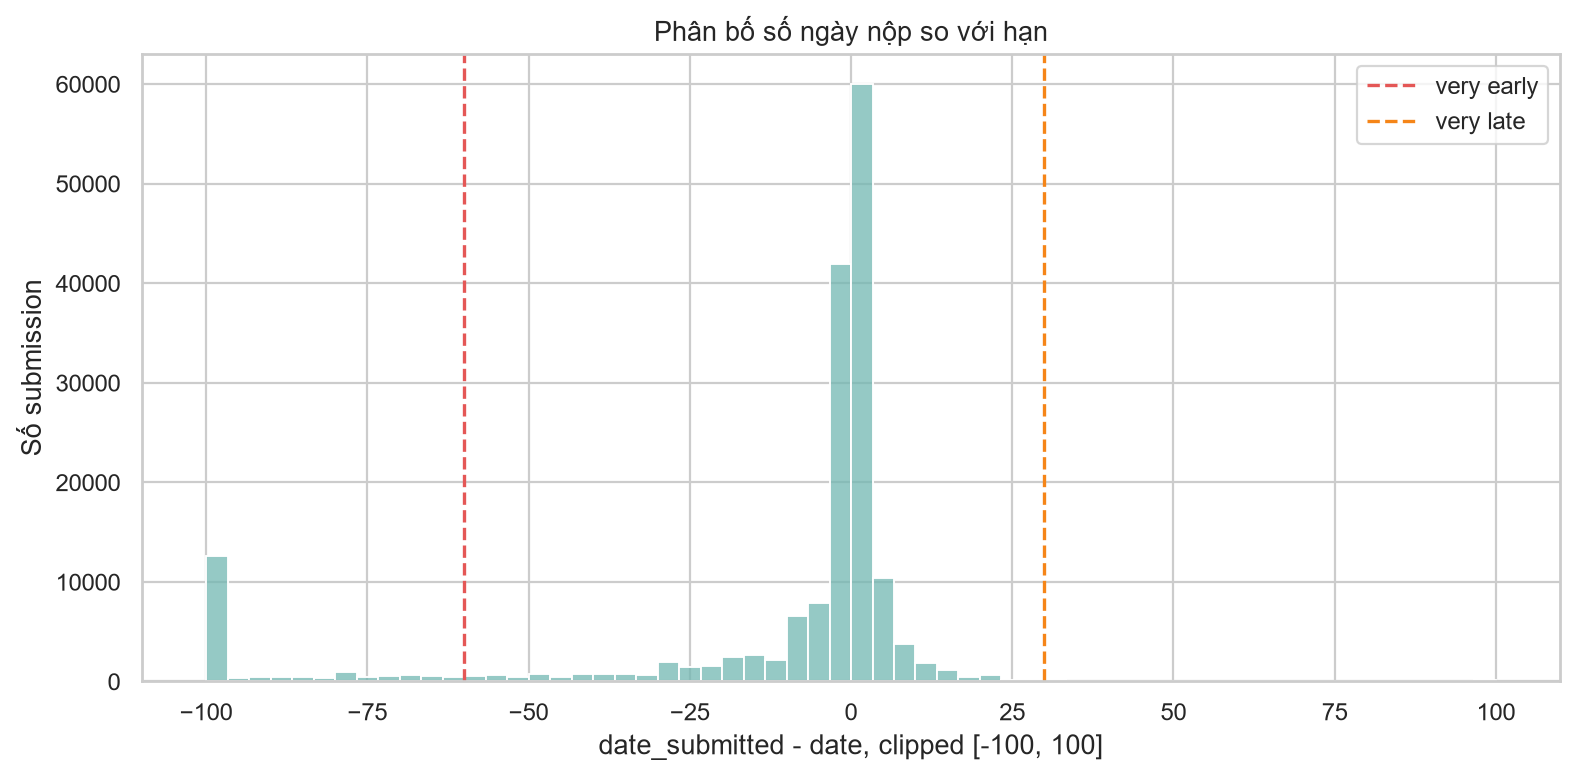

submission_timing_outliers_by_module_presentation.png


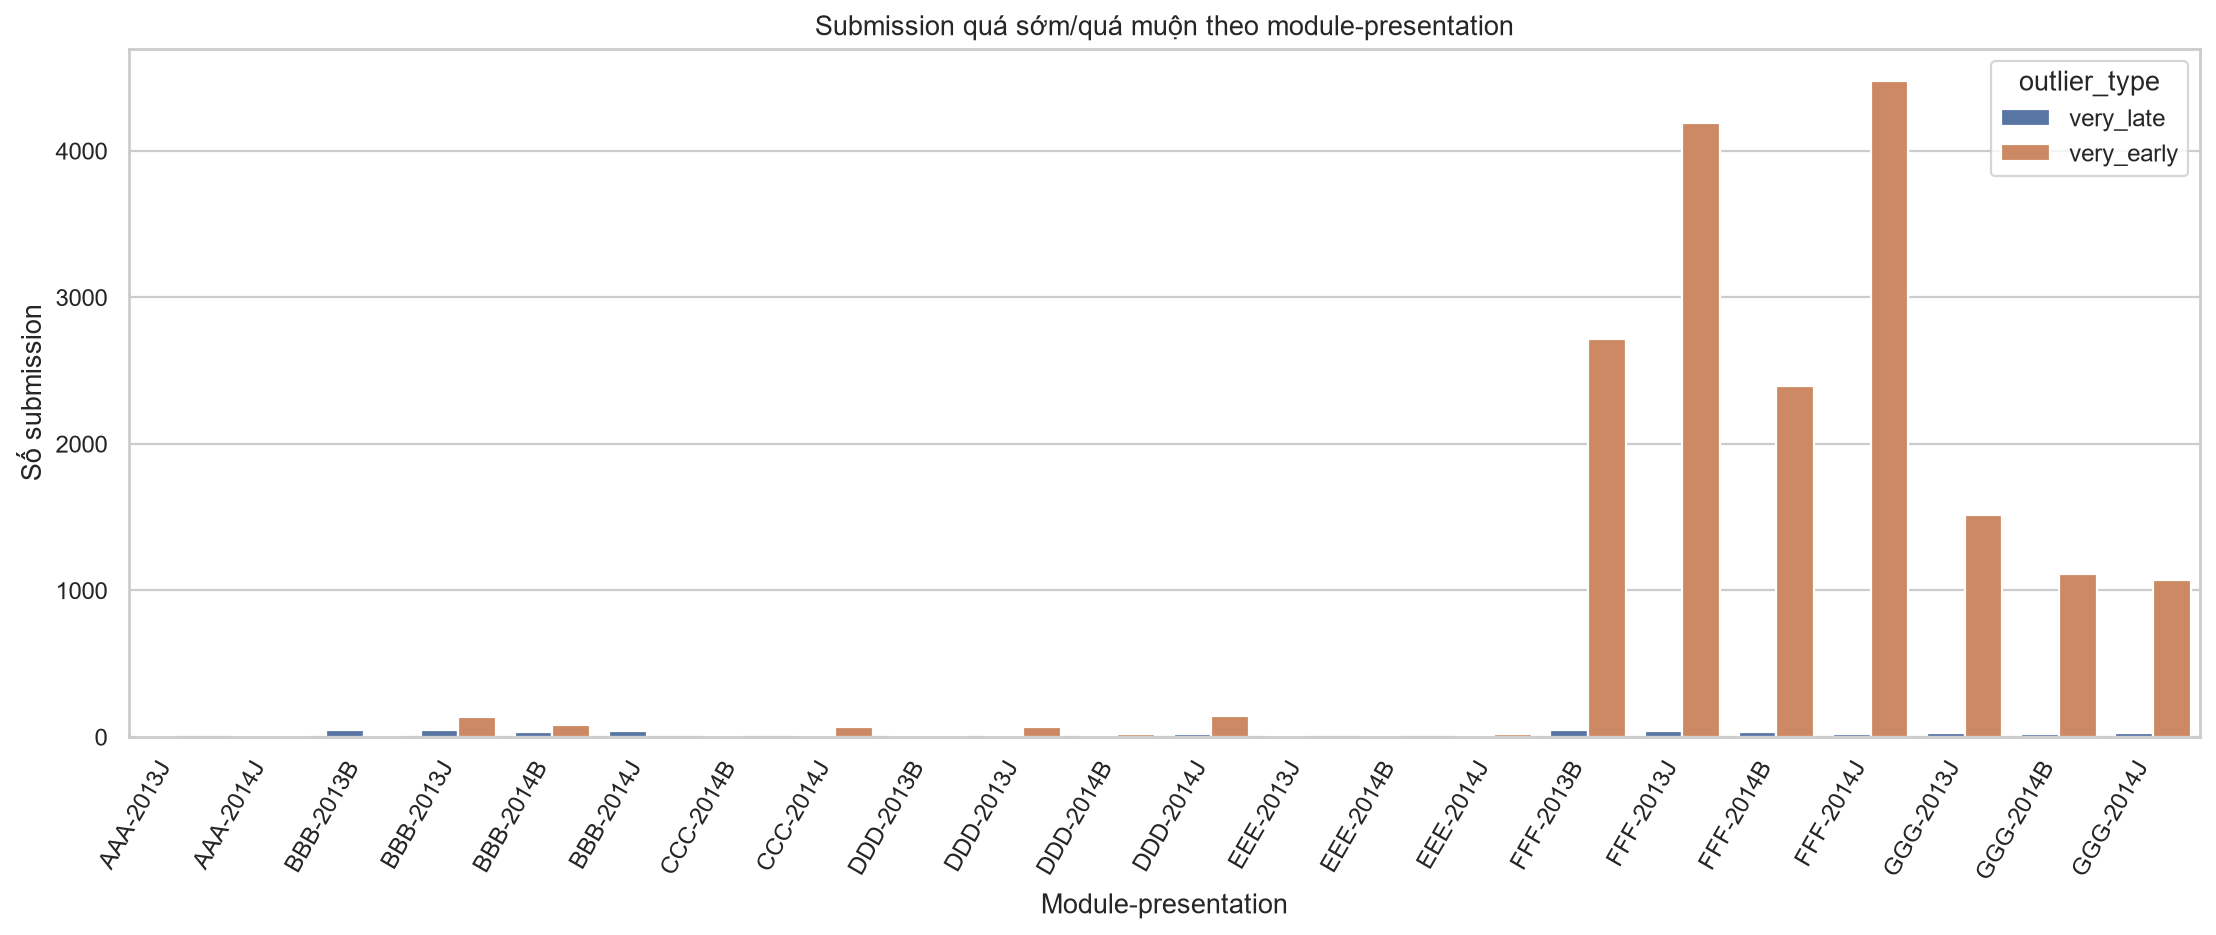

submission_timing_scatter_by_module_presentation.png


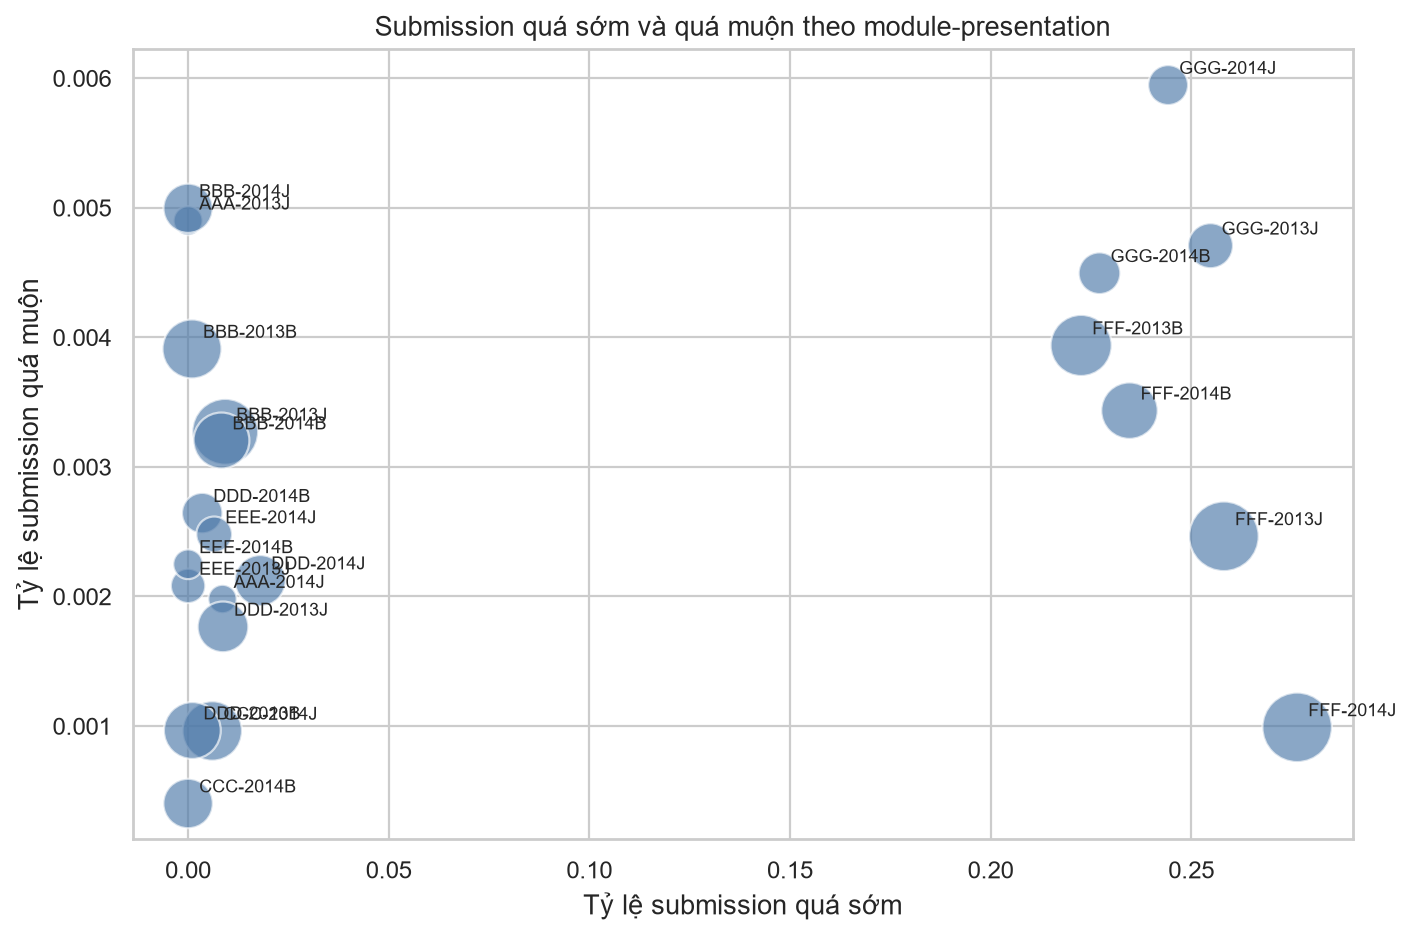

In [5]:
from IPython.display import Image

for figure in sorted(FIGURE_DIR.glob("*.png")):
    print(figure.name)
    display(Image(filename=str(figure)))